In [3]:
import numpy as np
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

from dataset_configs import get_all_configs
from dataset_configs import get_some_configs
from vacuum_plots_many import loader





The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
from masking import make_inclusion_mask
from processing import get_maps, prepare_maps
from configuration import get_file_config
from estimation import plot_extrapolation_estimate
from logger import setup_logger

logger = setup_logger()



2026-03-03 18:28:32,222: logger: INFO: Imposing high_resolution_limit: 1.7 (processing.py:39)


/Users/sbielfel/Nextcloud2/time_resolved/data/photolyase/6_10ns/10ns_deposit.mtz
/Users/sbielfel/Nextcloud2/time_resolved/data/photolyase/5_3ns/3ns_deposit.mtz
/Users/sbielfel/Nextcloud2/time_resolved/data/photolyase/7_30ns/30ns_deposit.mtz
/Users/sbielfel/Nextcloud2/time_resolved/data/photolyase/2_3ps/3ps_deposit.mtz


2026-03-03 18:28:33,139: logger: INFO: Loading preprocessed maps from OCP/OCP/diffmap_17.0_tv_110.mtz (processing.py:189)
2026-03-03 18:28:33,173: logger: INFO: Diffmap std: 0.004 (processing.py:564)
2026-03-03 18:28:33,174: logger: INFO: diffmap larger voxel count: 0.2588350272472994 (processing.py:565)
2026-03-03 18:28:33,253: logger: INFO: ignore_mask voxel count: 0.5149728280526621 (processing.py:242)
2026-03-03 18:28:33,265: logger: INFO: Shift value 0.32599 corresponds to zero frequency 174656.375 (processing.py:256)
2026-03-03 18:28:33,287: logger: INFO: calculating autoshift for triggered map... with extra mask (processing.py:571)
2026-03-03 18:28:33,369: logger: INFO: ignore_mask voxel count: 0.6714583031925154 (processing.py:242)
2026-03-03 18:28:33,385: logger: INFO: Shift value 0.32239 corresponds to zero frequency 172728.812 (processing.py:256)
2026-03-03 18:28:33,407: logger: INFO: calculating autoshift for triggered map... done (processing.py:575)
2026-03-03 18:28:33,408

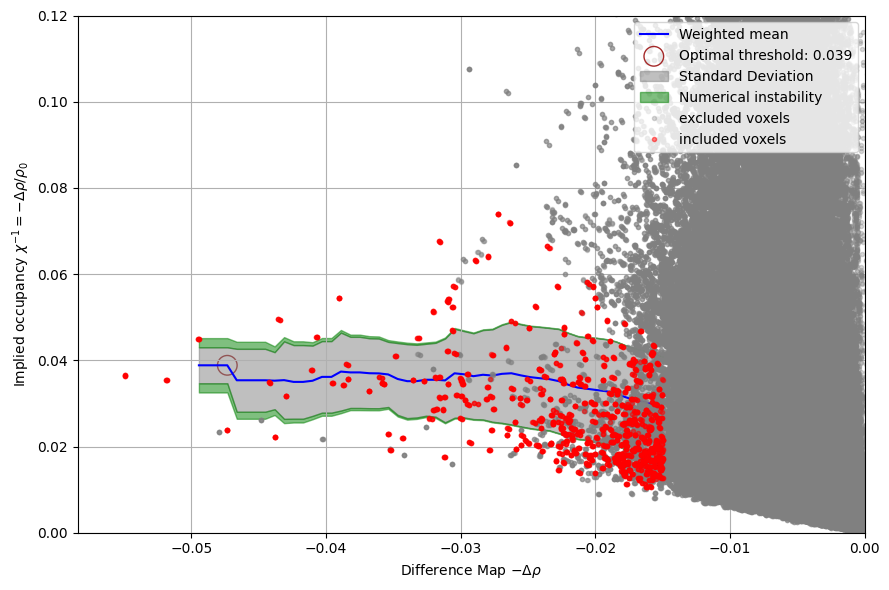

In [10]:
from estimation import _calculate_statistics, _analyze_threshold_trends


config = get_all_configs()[0]
unscaled_dark, unscaled_triggered = get_maps(config)
diffmap, map_dark, _ = prepare_maps(unscaled_dark, unscaled_triggered, config)

diffmap_np = diffmap.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])
logger.warning(
    f"Diffmap Mean: {diffmap_np.mean():.6f}, Std: {diffmap_np.std():.6f}"
)
inclusion_mask = make_inclusion_mask(diffmap, map_dark, config)
config["plot"]["set_ylim"] = ((0, 0.12))
fig, ax = plot_extrapolation_estimate(diffmap, map_dark, inclusion_mask, config)


2026-03-03 18:23:46,025: logger: INFO: Imposing high_resolution_limit: 1.7 (processing.py:39)


/Users/sbielfel/Nextcloud2/time_resolved/data/photolyase/6_10ns/10ns_deposit.mtz
/Users/sbielfel/Nextcloud2/time_resolved/data/photolyase/5_3ns/3ns_deposit.mtz


2026-03-03 18:23:46,920: logger: INFO: Loading preprocessed maps from OCP/OCP/diffmap_17.0_tv_110.mtz (processing.py:189)
2026-03-03 18:23:46,955: logger: INFO: Diffmap std: 0.004 (processing.py:564)
2026-03-03 18:23:46,956: logger: INFO: diffmap larger voxel count: 0.2588350272472994 (processing.py:565)
2026-03-03 18:23:47,038: logger: INFO: ignore_mask voxel count: 0.5149728280526621 (processing.py:242)
2026-03-03 18:23:47,051: logger: INFO: Shift value 0.32599 corresponds to zero frequency 174656.375 (processing.py:256)
2026-03-03 18:23:47,073: logger: INFO: calculating autoshift for triggered map... with extra mask (processing.py:571)
2026-03-03 18:23:47,154: logger: INFO: ignore_mask voxel count: 0.6714583031925154 (processing.py:242)
2026-03-03 18:23:47,170: logger: INFO: Shift value 0.32239 corresponds to zero frequency 172728.812 (processing.py:256)
2026-03-03 18:23:47,192: logger: INFO: calculating autoshift for triggered map... done (processing.py:575)
2026-03-03 18:23:47,192

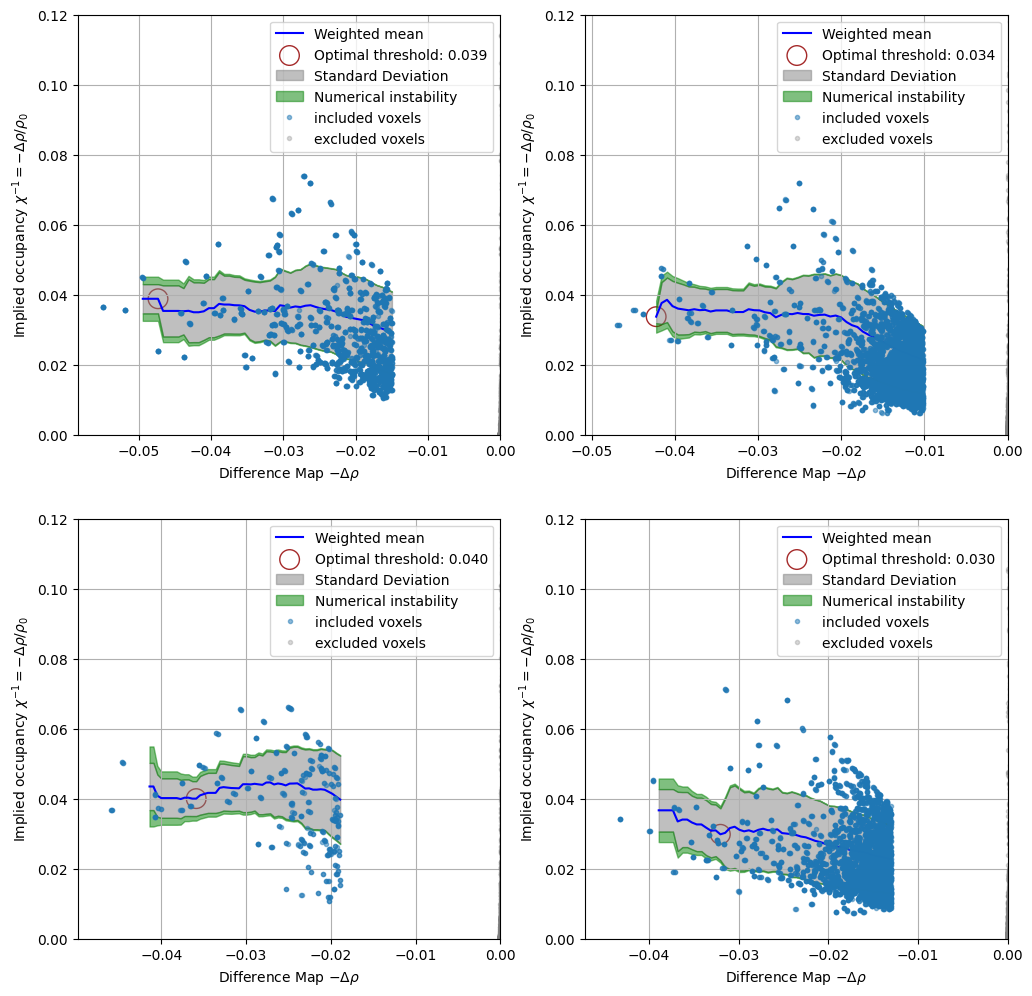

In [2]:

config_list = get_some_configs()
leng = len(config_list)//2+len(config_list)%2
fig, axs = plt.subplots(leng,2, figsize=(12, 6*leng))
for ax, config in zip(axs.flatten(), config_list):
    config["plot"]["set_ylim"] = ((0, 0.12))
    loader(config, ax)
plt.show()